## Self-Similar Solutions to the Thin-Film Equation

This notebook investigates the numerical construction of self-similar source-type solutions to the one-dimensional thin-film equation. The thin-film equation describes how a fluid that is very thin in height compared to the length travels over time on a one-dimensional flat solid surface. We consider the source-type thin-film equation

$$
\begin{aligned}
\partial_t u
&=
-\partial_x\left(|u|^n \partial_x^3 u\right),
\qquad x\in\mathbb{R}, \quad & t>0,
\\
u(x,0)
&=
c\delta(x),
\qquad & x\in\mathbb{R},
\end{aligned}
$$

where $u(x,t)$ denotes the film height and $n>0$ is the mobility exponent.

The solution is expected to have the self-similar form 

$$
u(x,t)
=
t^{-\alpha}f(\mu),
\qquad
\mu = xt^{-\alpha},
\qquad
\alpha=\frac{1}{n+4}.
$$

Substituting this into the thin-film equation reduces the PDE to the nonlinear ODE

$$
\begin{aligned}
& (|f(\mu)|^nf'''(\mu))' = \alpha (\mu f(\mu))', \qquad & \text{for } -\infty < \mu < \infty, \\
& \mu f(\mu) \to 0, \qquad & \text{as } \mu \to \pm \infty.
\end{aligned}
$$

Exploiting the scaling properties of the equation and rescaling the variables reduces the ODE to

$$
\begin{aligned}
u^{n-1}u'''
&=
x,
\qquad
u>0,
\qquad
0<x<a,
\\
u(0)
&=
1,
\qquad
u'(0)=0,
\\
u(a)
&=
0,
\qquad
u'(a)=0.
\end{aligned}
$$

The solution is symmetric and strictly decreasing on the interval $0<x<a$. A nontrivial compactly supported solution exists and is unique only for $0<n<3$.

The goal is to numerically construct compactly supported, symmetric, nonnegative self-similar solutions satisfying the required boundary and mass conditions.

<br>
<br>

To numerically construct the self-similar solution, we note that the location of the free boundary $x=a$ is unknown beforehand. Therefore, the problem is a free-boundary problem: both the solution $u(x)$ and the endpoint $a$ satisfying

$$
u(a)=0,
\qquad
u'(a)=0
$$

must be determined simultaneously.

To overcome this difficulty, the nonlinear boundary value problem is reformulated as a shooting problem. Instead of prescribing the free boundary location $a$, we prescribe an initial curvature parameter $\gamma$ and solve the corresponding initial value problem

$$
\begin{cases}
u''' = xu^{1-n},
& u>0,
\qquad x>0,
\\
u(0)=1,
\qquad
u'(0)=0,
\qquad
u''(0)=-\gamma,
\end{cases}
$$

where $\gamma>0$ is the shooting parameter.

For each choice of $\gamma$, the resulting initial value problem is integrated numerically. Depending on the value of $\gamma$, the solution may:
- remain positive,
- become negative,
- or touch zero with the desired free-boundary behavior.

The correct value of $\gamma$ is determined using a bisection-based shooting procedure. Two initial values $\gamma_-$ and $\gamma_+$ are chosen such that the corresponding solutions exhibit qualitatively different behavior. For example:
- $\gamma_-$ produces a solution for which there exists a point $b$ satisfying $u(b)=0$ and $u'(b)<0$,
- $\gamma_+$ produces a solution for which there exists a point $b$ satisfying $u(b)>0$ and $u'(b)=0$.

The interval $[\gamma_+,\gamma_-]$ is repeatedly refined until the critical value of $\gamma$ producing the desired compactly supported self-similar solution is obtained.

<br>
<br>

The self-similar solution is constructed for multiple values of $n$. Throughout the experiments we set $c=1$, use the initial values $\gamma_-=10$ and $\gamma_+=0.001$, and integrate over a maximum domain of $x=10^6$.

For the numerical integration, the maximum timestep is chosen as

$$
\Delta x_{\max}=0.01.
$$

The integration is terminated once either

$$
|u|<10^{-10}
\qquad
\text{or}
\qquad
|u'|<10^{-10}.
$$

A maximum of 1000 iterations is used for the bisection method.

## Running the Experiments

Run all cells sequentially to reproduce the numerical experiments and self-similar solution figures.

### Loading the needed packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.fft import fft, ifft, fftfreq
import warnings

warnings.filterwarnings("ignore")

### Defining the parameters

In [2]:
#Defining the different 0 < n < 3
nvalues = [0.1, 0.5, 1, 1.5, 2, 2.5, 2.9]

#Setting the mass of the droplet
c = 1

#Defining the starting parameters gamma, where gamma_plus is in S+ and gamma_minus is in S-
gamma_minus = 10
gamma_plus = 0.001

#Setting the maximum step size and xmax
Dx = 0.01
xmax = 1e6

#Defining a bound for u and u_prime
bound = 1e-10

#Max iterations for the bisection method
max_iter = 1000

### The Nonlinear System

In [3]:
def f(x: float, n: float, u: np.ndarray) -> np.ndarray:
    """
    The nonlinear system.

    Parameters:
        x (float): x value.
        n (float): n value.
        u (np.ndarray): array with value u, u' and u'' at point x.

    Returns:
        f (np.ndarray): array with the values evaluated in the nonlinear system at x.
    """
    u1, u2, u3 = u
    return np.array([u2,u3,x*float(u1)**(1-n)])

### Time Integration

In [4]:
#These two functions make sure that the solver terminates when u or u' hit zero
def u_is_zero(x: float, y: float) -> float:
    return y[0]

u_is_zero.terminal = True
u_is_zero.direction = -1

def u_prime_is_zero(x: float, y: float) -> float:
    return y[1]

u_prime_is_zero.terminal = True
u_prime_is_zero.direction = 1


def TimeIntegration(Dx: float, xmax: float, n: float, u_0: np.ndarray) -> tuple:
    """
    The time integration method. Uses the built-in scipy function "solve_ivp".

    Parameters:
        Dx (float): update step size.
        xmax (float): maximum x value before the function terminates.
        n (float): n value.
        u_0 (np.ndarray): array with the initial values.

    Returns:
        u_values, x_values, u, u_prime (tuple): u_values and x_values after time integration and u and u_prime at the last integration timestep.
    """
    sol = solve_ivp(
        lambda x, y: f(x, n, y),
        [0,xmax],
        u_0,
        events =[u_is_zero,u_prime_is_zero],
        rtol = 1e-16,
        atol = 1e-16,
        max_step = Dx
    )

    return sol.y[0], sol.t, sol.y[0][-1], sol.y[1][-1]

### The Bisection Method

In [5]:
def Bisection(Dx: float, xmax: float, n: float, gamma_minus: float, gamma_plus: float, bound: float, max_iter: float) -> tuple:
    """
    The bisection method. Used to find the correct gamma such that u and u' become simultaniously zero.

    Parameters:
        Dx (float): update step size.
        xmax (float): maximum x value before the function in TimeIntegration terminates.
        n (float): n value.
        gamma_minus (float): gamma value which is in the set S-.
        gamma_plus (float): gamma value which is in the set S+.
        bound (float): bound for u and u' which they need to satisfy in order to find the correct gamma.
        max_iter (float): maximum number of iterations of the bisection method before it terminates.

    Returns:
        u_values, x_values, opt_gamma, u, u_prime (tuple): u_values of the optimal gamma, x_values of the optimal gamma
                                                         and u and u_prime are the exact values at the last timestep of the optimal gamma.
    """

    #Defining the initial values for S- and S+ and performing time integration
    u_0_minus = np.array([1,0,-gamma_minus])
    u_0_plus = np.array([1,0,-gamma_plus])

    _, _, _, u_prime = TimeIntegration(Dx = Dx, xmax = xmax, n = n, u_0 = u_0_plus)
    _, _, u, _ = TimeIntegration(Dx = Dx, xmax = xmax, n = n, u_0 = u_0_minus)

    #Defining the iteration parameter
    iter = 0

    #A while loop to keep performing the bisection method until it hits the correct gamma or max iterations
    while True:
        #Defining a new gamma by taking the average of gamma+ and gamma- and performing time integration
        new_gamma = (gamma_minus + gamma_plus)/2
        u_0 = np.array([1,0,-new_gamma])
        u_values, x_values, u, u_prime, = TimeIntegration(Dx = Dx, xmax = xmax, n = n, u_0 = u_0)

        #If the correct gamma is found which satisfy the bounds, the values are returned
        if u<bound and -u_prime<bound:
            return u_values, x_values, new_gamma, u, u_prime
        
        #Updating the iteration step and if it hits the max iterations, the function terminates
        iter += 1
        if iter == max_iter:
            print("Max Iterations hit")
            return u_values, x_values, new_gamma, u, u_prime 
        
        #Checking in which set our new gamma is and updating our old gamma in order to apply the bisection method again
        if u < bound:
            gamma_minus = new_gamma
        else:
            gamma_plus = new_gamma

### Mass Conversation

In [6]:
def TrapezoidalRule(x_values: np.ndarray, u_values: np.ndarray) -> float:
    """
    The trapezoidal rule for integrals. Uses the trapezoidal rule with composition.

    Parameters:
        x_values (np.ndarray): x values of the numerically approached ODE.
        u_values (np.ndarray): u values of the numerically approached ODE.

    Returns:
        integralvalue (float): value of the integral using trapezoidal rule.
    """
    res = 0
    for i in range(len(x_values)-1):
        res += (x_values[i+1]-x_values[i])/2 * (np.abs(u_values[i])+np.abs(u_values[i+1]))
    return res



def Original_ODE(c: float, alpha: float, x_values: np.ndarray, u_values: np.ndarray, HeatEquation: bool = False) -> tuple:
    """
    Returns the original ODE.

    Parameters:
        c (float): mass of the droplet.
        alpha (float): self-similar value.
        x_values (np.ndarray): x values of the numerically approached ODE.
        u_values (np.ndarray): u values of the numerically approached ODE.
        HeatEquation (bool): this parameter is used to change the grid size when comparing to the biharmonic heat equation.
                             Standard value is False.

    Returns:
        new_x_values, new_u_values, support, l, k (tuple): new_x_values is an array of the new x values, new_u_values is an array of the
                                                         original u values, support is the x value where u and u' hit zero for the original
                                                         ODE, l and k are the values that are needed for the transformation to the original ODE.
    """

    #Calculating the k and l value
    norm1 = 2*TrapezoidalRule(x_values = x_values, u_values = u_values)
    k = ((alpha*c**4)/norm1**4)**(alpha)
    l = (k*norm1)/c

    #Determining the x value where u and u' hit zero for the original ODE
    support = x_values[-1]/l

    #Creating an interpolation function in order to get get the transformation function f(x) = k*u(l*x)
    outside_support_x = np.linspace(x_values[-3],support+10, num = 100000)
    outside_support_u = np.zeros(100000)
    u_interp = interp1d(np.concatenate((x_values[:-10],outside_support_x)),
                        np.concatenate((u_values[:-10],outside_support_u)), kind='cubic',fill_value='extrapolate', bounds_error = False)


    #Getting the new x and u values
    if HeatEquation:
        new_x_values = np.linspace(0,support+5*support, num = 3000)
    else:
        new_x_values = np.linspace(0,support+support/10, num = 300)
    new_u_values = k*u_interp(l*new_x_values)

    #Mirroring the values by symmetry
    new_u_values = np.concatenate((new_u_values[::-1], new_u_values[1:]))
    new_x_values = np.concatenate((-new_x_values[::-1], new_x_values[1:]))

    return new_x_values, new_u_values, support, l, k

### The Results

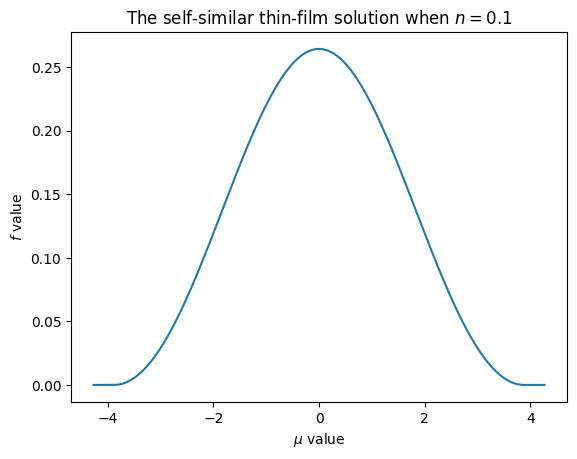

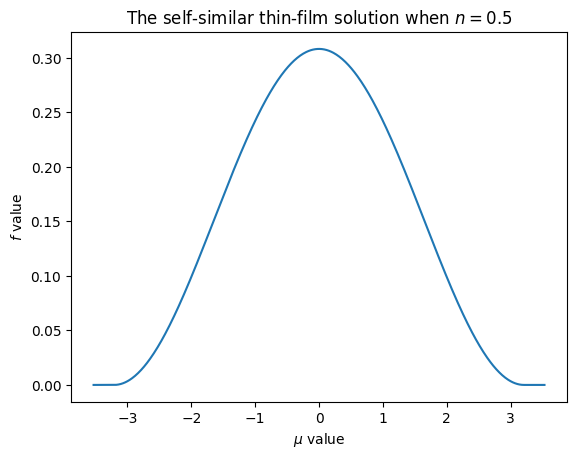

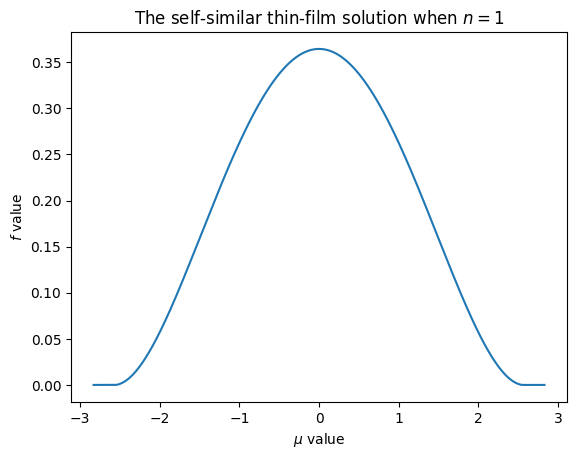

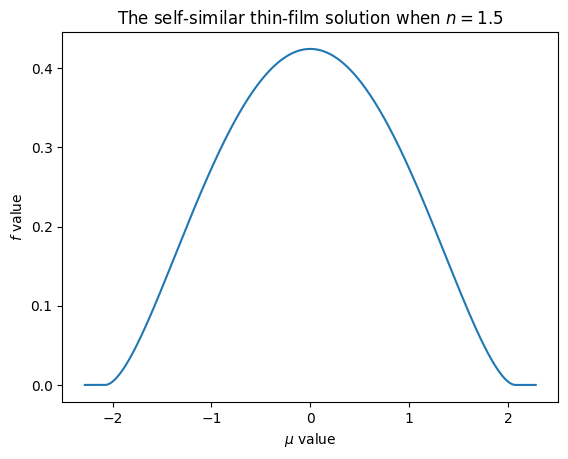

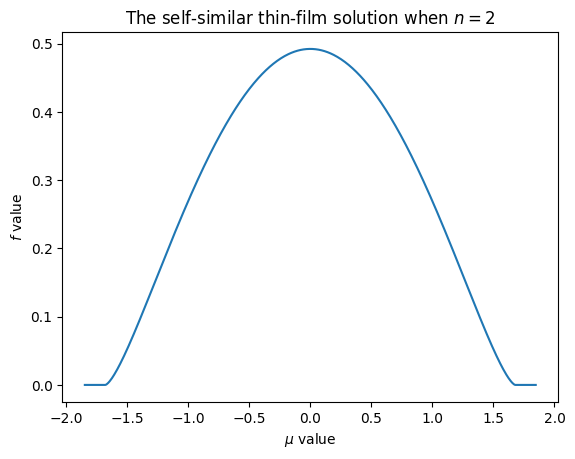

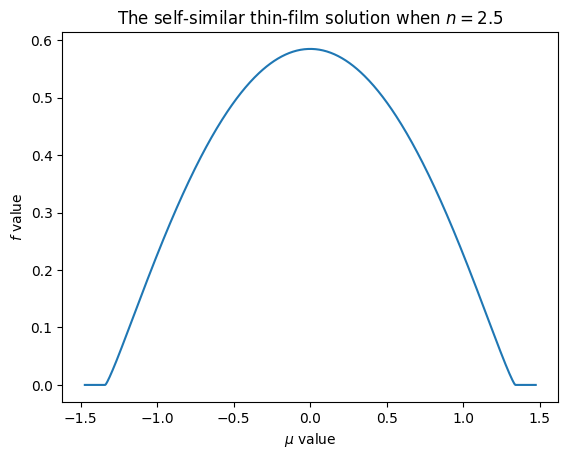

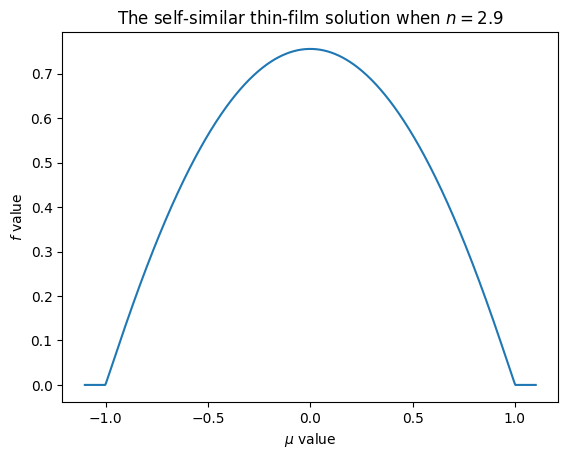

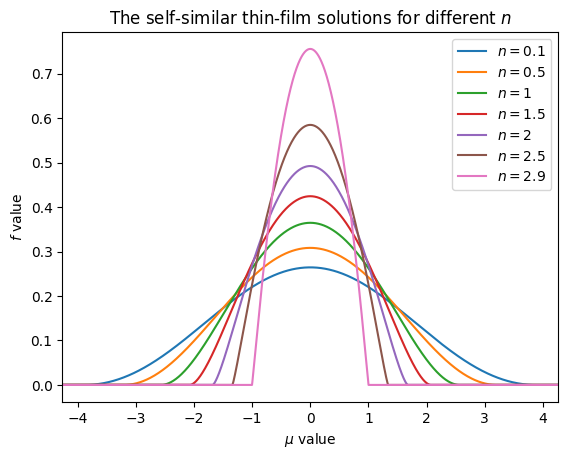

   n value |                 gamma_0 |                       a |                    f(a) |                   f'(a) |           integral of f
--------------------------------------------------------------------------------------------------------------------------------------------
  0.100000 |    0.675056568318032069 |    3.878676823621447944 |   -0.000000000212514567 |   -0.000000000000000086 |    1.000001426014373695
  0.500000 |    0.728219633608025108 |    3.209793163697717056 |    0.000000000021473220 |    0.000000000000000095 |    1.000002316628070931
  1.000000 |    0.816496582504361745 |    2.571760394235148794 |   -0.000000001407821850 |    0.000000000000000056 |    0.999988952083460836
  1.500000 |    0.947080658948776355 |    2.074482433956521987 |    0.000000000003368148 |    0.000000000000000167 |    1.000003653954015803
  2.000000 |    1.168952585503459263 |    1.678887091440652179 |    0.000000000026652429 |   -0.000000000001384364 |    1.000003337656091729
  2.500000 | 

In [7]:
#Defining lists where the optimal values will be stored
u_zero = []
u_prime_zero = []
gamma_opts = []
x_value_zero = []
masses = []

#Storing the support and x and u values for one plot with all n values
x_values_stored = []
u_values_stored = []
support_stored = []

#A loop is done for all the n values
for n in sorted(nvalues):

    #Here the optimal gamma with the x and u values are calculated
    u_values, x_values, gamma_opt, u, u_prime = Bisection(Dx = Dx, xmax = xmax, n = n,
                                                                        gamma_minus = gamma_minus, gamma_plus = gamma_plus,
                                                                        bound = bound, max_iter = max_iter)
    
    gamma_opts.append(gamma_opt)

    #Here the orginal x and u values of the ODE are returned
    alpha = 1/(n+4)
    original_x_values, original_u_values, support, l, k = Original_ODE(c = c, alpha = alpha, x_values = x_values, u_values = u_values)

    u_zero.append(u*k)
    u_prime_zero.append(u_prime*k*l)
    x_value_zero.append(support)

    #Here the mass is calculated
    masses.append(TrapezoidalRule(x_values = original_x_values, u_values = original_u_values))

    support_stored.append(support)
    u_values_stored.append(original_u_values.tolist())
    x_values_stored.append(original_x_values.tolist())

    #Plotting the different n values
    plt.plot(original_x_values, original_u_values)
    plt.title(f"The self-similar thin-film solution when $n = {n}$")
    plt.xlabel("$\mu$ value")
    plt.ylabel("$f$ value")
    plt.show()

#Plotting the different n values in one plot
for i, n in enumerate(nvalues):

    x_values_stored = np.array(x_values_stored)
    u_values_stored = np.array(u_values_stored)

    outside_support_x1 = np.linspace(-max(support_stored)-2,x_values_stored[i,0], num = 10)
    outside_support_x2 = np.linspace(x_values_stored[i,-1], max(support_stored)+2, num = 10)
    outside_support_u = np.zeros(10)

    plt.plot(np.concatenate((outside_support_x1, x_values_stored[i], outside_support_x2)),
                np.concatenate((outside_support_u, u_values_stored[i], outside_support_u)), label = f"$n = {n}$")



plt.xlim(-max(support_stored)-max(support_stored)/10, max(support_stored)+max(support_stored)/10)
plt.ylim(-np.max(u_values_stored)/20, np.max(u_values_stored)+np.max(u_values_stored)/20)
plt.title(f"The self-similar thin-film solutions for different $n$")
plt.xlabel("$\mu$ value")
plt.ylabel("$f$ value")
plt.legend()
plt.show()


#Printing the values
print("{:>10s} | {:>23s} | {:>23s} | {:>23s} | {:>23s} | {:>23s}".format('n value', 'gamma_0', 'a', 'f(a)', "f'(a)", 'integral of f'))
print("-"*140)
for n, gamma_opt, x_zero, u, u_prime, mass in zip(nvalues, gamma_opts, x_value_zero, u_zero, u_prime_zero, masses):
    print('{:>10f} | {:>23.18f} | {:>23.18f} | {:>23.18f} | {:>23.18f} | {:>23.18f}'.format(n, gamma_opt, x_zero, u, u_prime, mass))